<a href="https://colab.research.google.com/github/liyenrondon/IA-2/blob/main/Titanic_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importo pandas para trabajar con los datos en forma de tablas.
import pandas as pd

# Importo numpy para realizar operaciones numéricas.
import numpy as np

# Importo matplotlib para crear gráficos.
import matplotlib.pyplot as plt

# Importo seaborn para crear gráficos estadísticos.
import seaborn as sns

# Importo el árbol de decisión que voy a utilizar para predecir la supervivencia.
from sklearn.tree import DecisionTreeClassifier

# Importo la función que permite separar los datos para entrenar y comprobar el modelo.
from sklearn.model_selection import train_test_split

# Importo la métrica que voy a utilizar para medir la precisión del modelo.
from sklearn.metrics import accuracy_score

# Cargo los datos de entrenamiento que tienen la información y la respuesta de supervivencia.
train = pd.read_csv("/content/train.csv")

# Cargo los datos de prueba que utilizaré para realizar las predicciones finales.
test = pd.read_csv("/content/test.csv")

# Muestro el tamaño de los datos de entrenamiento.
print("Tamaño de los datos de entrenamiento:", train.shape)

# Muestro el tamaño de los datos de prueba.
print("Tamaño de los datos de prueba:", test.shape)

# Muestro las primeras filas para conocer cómo están organizados los datos.
print("\nPrimeras filas de los datos:")
display(train.head())

# Muestro la cantidad de datos vacíos que tiene cada columna.
print("\nDatos faltantes:")
print(train.isnull().sum())

# Creo un gráfico para observar cuántas personas sobrevivieron y cuántas no.
sns.countplot(x="Survived", data=train)

# Agrego un título al gráfico.
plt.title("Supervivencia de los pasajeros")

# Muestro el gráfico.
plt.show()

# Creo una copia de los datos para poder prepararlos sin modificar los originales.
datos = train.copy()

# Convierto el sexo de texto a números para que el modelo pueda utilizarlo.
datos["Sex"] = datos["Sex"].map({"male": 0, "female": 1})

# Completo las edades que faltan utilizando la mediana.
datos["Age"] = datos["Age"].fillna(datos["Age"].median())

# Convierto los puertos de embarque en números.
datos["Embarked"] = datos["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Completo los puertos de embarque que estén vacíos.
datos["Embarked"] = datos["Embarked"].fillna(datos["Embarked"].mode()[0])

# Selecciono las características que voy a utilizar para hacer la predicción.
X = datos[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]

# Selecciono la variable que quiero predecir.
y = datos["Survived"]

# Separo el 80% de los datos para entrenar y el 20% para comprobar el modelo.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Creo el árbol de decisión con una profundidad máxima para evitar que aprenda demasiado los datos.
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)

# Entreno el modelo utilizando los datos de entrenamiento.
modelo.fit(X_train, y_train)

# Utilizo el modelo para predecir los pasajeros que dejamos para comprobar.
predicciones = modelo.predict(X_valid)

# Calculo qué porcentaje de las predicciones fueron correctas.
precision = accuracy_score(y_valid, predicciones)

# Muestro la precisión obtenida por el modelo.
print("\nPrecisión del modelo:", precision)

# Creo una copia de los datos de prueba para prepararlos de la misma manera.
test_procesado = test.copy()

# Convierto el sexo a números.
test_procesado["Sex"] = test_procesado["Sex"].map({"male": 0, "female": 1})

# Completo las edades que estén vacías.
test_procesado["Age"] = test_procesado["Age"].fillna(datos["Age"].median())

# Convierto los puertos de embarque a números.
test_procesado["Embarked"] = test_procesado["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Completo los puertos de embarque vacíos.
test_procesado["Embarked"] = test_procesado["Embarked"].fillna(datos["Embarked"].mode()[0])

# Completo las tarifas que estén vacías.
test_procesado["Fare"] = test_procesado["Fare"].fillna(datos["Fare"].median())

# Selecciono las mismas características utilizadas para entrenar el modelo.
X_test = test_procesado[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]

# Entreno un nuevo modelo utilizando todos los datos disponibles.
modelo_final = DecisionTreeClassifier(max_depth=4, random_state=42)

# El modelo aprende utilizando todos los pasajeros del conjunto de entrenamiento.
modelo_final.fit(X, y)

# Realizo la predicción de supervivencia para los pasajeros de test.
predicciones_test = modelo_final.predict(X_test)

# Creo el archivo final con el identificador del pasajero y su predicción.
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predicciones_test
})

# Guardo las predicciones en un archivo CSV.
submission.to_csv("submission.csv", index=False)

# Muestro las primeras predicciones para comprobar que todo salió correctamente.
print("\nPrimeras predicciones:")
display(submission.head())

# Informo que el archivo fue creado correctamente.
print("\n✅ Archivo submission.csv creado correctamente.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/train.csv'

### Visualización de la Supervivencia por Clase (Pclass)

/tmp/ipykernel_7222/778026309.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train, palette='viridis')


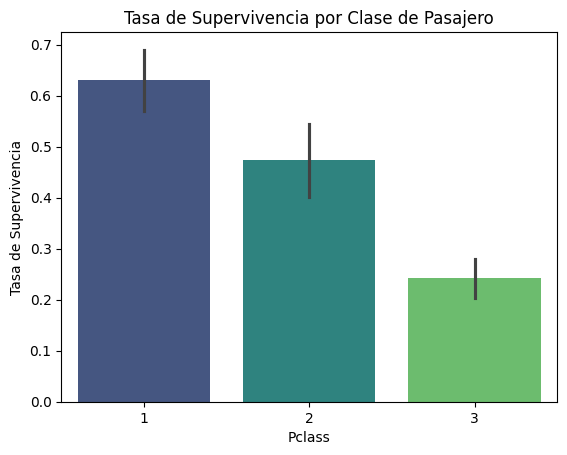

In [ ]:
# Supervivencia por Pclass
sns.barplot(x='Pclass', y='Survived', data=train, palette='viridis')
plt.title('Tasa de Supervivencia por Clase de Pasajero')
plt.ylabel('Tasa de Supervivencia')
plt.show()

### Visualización de la Supervivencia por Sexo

/tmp/ipykernel_7222/3032373850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=train, palette='magma')


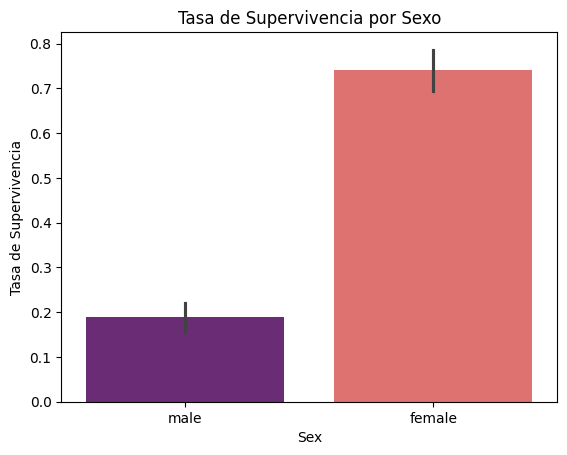

In [ ]:
# Supervivencia por Sexo
sns.barplot(x='Sex', y='Survived', data=train, palette='magma')
plt.title('Tasa de Supervivencia por Sexo')
plt.ylabel('Tasa de Supervivencia')
plt.show()

### Visualización de la Supervivencia por Puerto de Embarque

/tmp/ipykernel_7222/2317606245.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=train, palette='cividis')


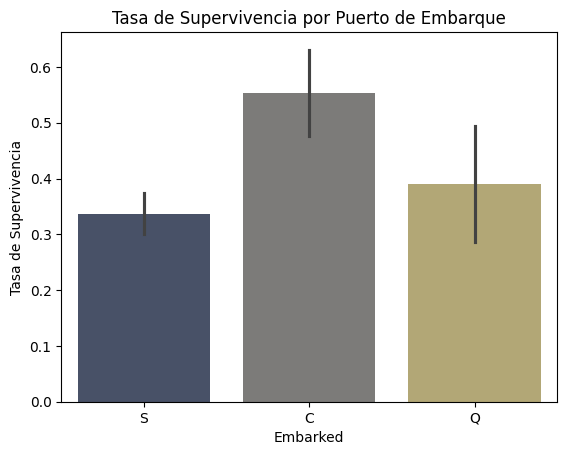

In [ ]:
# Supervivencia por Embarked
sns.barplot(x='Embarked', y='Survived', data=train, palette='cividis')
plt.title('Tasa de Supervivencia por Puerto de Embarque')
plt.ylabel('Tasa de Supervivencia')
plt.show()

### Distribución de Edades para Sobrevivientes y No Sobrevivientes

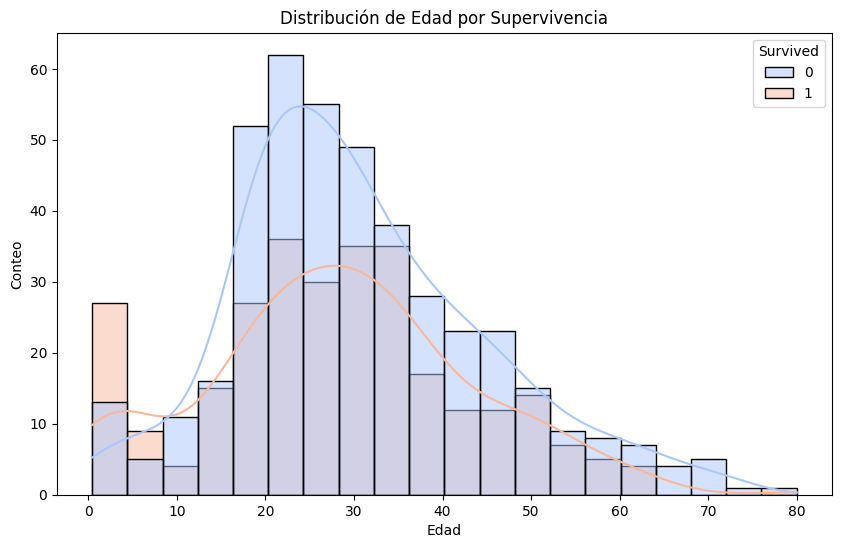

In [ ]:
# Distribución de Edad para Survived vs. Not Survived
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='Age', hue='Survived', kde=True, palette='coolwarm')
plt.title('Distribución de Edad por Supervivencia')
plt.xlabel('Edad')
plt.ylabel('Conteo')
plt.show()

### Distribución de Tarifas para Sobrevivientes y No Sobrevivientes

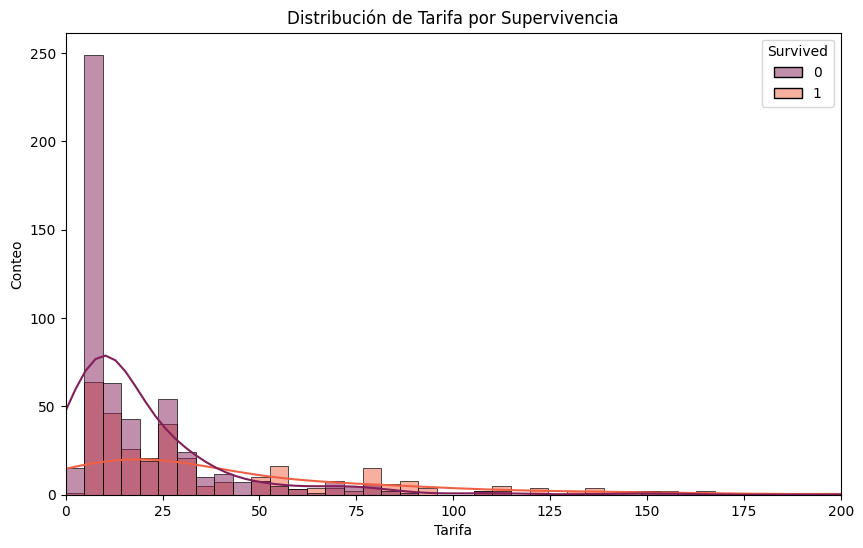

In [ ]:
# Distribución de Tarifa para Survived vs. Not Survived
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='Fare', hue='Survived', kde=True, palette='rocket')
plt.title('Distribución de Tarifa por Supervivencia')
plt.xlabel('Tarifa')
plt.ylabel('Conteo')
plt.xlim(0, 200) # Limitar el eje x para una mejor visualización de la mayoría de los datos
plt.show()

## Explicación Final del Análisis de Supervivencia del Titanic

Este análisis tuvo como objetivo predecir la supervivencia de los pasajeros del Titanic basándose en diversas características. A continuación, se detalla el proceso, lo que muestran los gráficos y las principales conclusiones:

**1. Objetivo del Análisis:**
El principal propósito fue construir un modelo predictivo capaz de estimar la probabilidad de que un pasajero sobreviviera al hundimiento del Titanic, utilizando sus atributos personales y de viaje.

**2. Carga y Preparación de Datos:**
*   Se cargaron dos conjuntos de datos: `train.csv` (para entrenar el modelo, ya que contiene la variable objetivo 'Survived') y `test.csv` (para generar las predicciones finales).
*   **Preprocesamiento Crítico:**
    *   **Manejo de Valores Faltantes:** Las edades (`Age`) se rellenaron con la mediana y los puertos de embarque (`Embarked`) con el valor más frecuente. Esto es fundamental, ya que los modelos de Machine Learning no pueden procesar datos incompletos.
    *   **Transformación de Variables Categóricas:** Las variables textuales como 'Sex' (sexo) y 'Embarked' (puerto de embarque) se convirtieron a representaciones numéricas (por ejemplo, 'male' -> 0, 'female' -> 1) para que el modelo pudiera interpretarlas y utilizarlas en sus cálculos.

**3. Exploración de Datos y Visualizaciones (Gráficos):**
Los gráficos generados son cruciales para entender las relaciones en los datos y los factores que influyeron en la supervivencia:
*   **Gráfico de Barras de Supervivencia por Clase (`Pclass`):** Este gráfico mostró una clara tendencia: la tasa de supervivencia fue significativamente mayor en la primera clase, disminuyendo progresivamente en la segunda y siendo la más baja en la tercera clase. Esto resalta la importancia del estatus socioeconómico en la tragedia.
*   **Gráfico de Barras de Supervivencia por Sexo (`Sex`):** Reveló el factor más influyente. Las mujeres tuvieron una tasa de supervivencia drásticamente más alta que los hombres, lo que confirma la implementación de la política de "mujeres y niños primero" durante el rescate.
*   **Gráfico de Barras de Supervivencia por Puerto de Embarque (`Embarked`):** Aunque con menos impacto que el sexo o la clase, se observaron diferencias en la supervivencia según el puerto de embarque. Los pasajeros que embarcaron en Cherbourg (C) tuvieron una tasa ligeramente superior.
*   **Histograma de Distribución de Edades por Supervivencia (`Age`):** Este gráfico mostró que los niños pequeños (especialmente los menores de 10 años) tuvieron una mayor probabilidad de sobrevivir. También se pudo observar que ciertos grupos de edad (hombres jóvenes y de mediana edad) tenían tasas de supervivencia más bajas.
*   **Histograma de Distribución de Tarifas por Supervivencia (`Fare`):** Los pasajeros que pagaron tarifas más altas (lo que generalmente se correlaciona con viajar en clases superiores y, por ende, tener acceso a botes salvavidas antes) mostraron una mayor tendencia a sobrevivir.

**4. Construcción y Evaluación del Modelo Predictivo:**
*   Se utilizó un **Árbol de Decisión (`DecisionTreeClassifier`)** como modelo predictivo. Este tipo de modelo es relativamente fácil de interpretar, lo que ayuda a entender cómo toma sus decisiones.
*   Para asegurar la robustez del modelo, los datos de entrenamiento se dividieron en un 80% para *entrenamiento* y un 20% para *validación*. Esta separación permite evaluar el rendimiento del modelo en datos que no ha visto previamente, evitando el "sobreajuste" (overfitting).
*   El modelo alcanzó una **precisión de aproximadamente 79.89%** en los datos de validación. Esto significa que fue capaz de clasificar correctamente a casi 8 de cada 10 pasajeros como supervivientes o no supervivientes en el conjunto de validación.

**5. Generación de Predicciones Finales:**
*   Finalmente, el modelo entrenado se aplicó a los datos de prueba (`test.csv`) para predecir la supervivencia de los pasajeros de los que no se conocía el resultado.
*   Se creó un archivo `submission.csv` que contiene el `PassengerId` de cada pasajero de prueba y la predicción de supervivencia (`0` para no sobrevivir, `1` para sobrevivir). Este archivo es el resultado final del proceso, listo para ser entregado o utilizado en un contexto real.

**Conclusión y Aspectos Más Importantes:**
El análisis y los gráficos confirman que el hundimiento del Titanic fue una tragedia donde los factores sociales y demográficos jugaron un papel crucial en la supervivencia. **El sexo y la clase del pasajero emergieron como los predictores más potentes.** Ser mujer y/o viajar en primera clase incrementaba significativamente las posibilidades de sobrevivir. La edad y la tarifa también tuvieron su importancia, a menudo correlacionadas con la clase.

Este modelo no solo predice resultados, sino que también ofrece una visión cuantitativa de los factores históricos que determinaron quién vivió y quién murió en la catástrofe del Titanic.